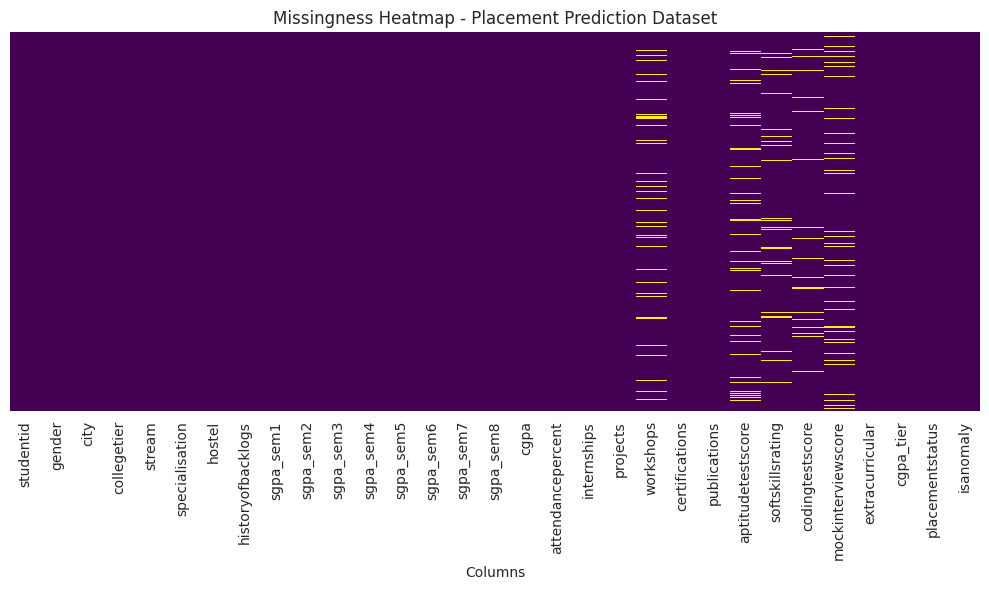

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking

df = pd.read_csv('/content/placement_predict_50k.csv')

# Standardize column names in the DataFrame to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Update num_cols to match the standardized column names in the DataFrame
num_cols = ['cgpa', 'attendancepercent', 'aptitudetestscore',
            'codingtestscore', 'softskillsrating', 'salary_package']

fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

KeyError: 'salary_package'

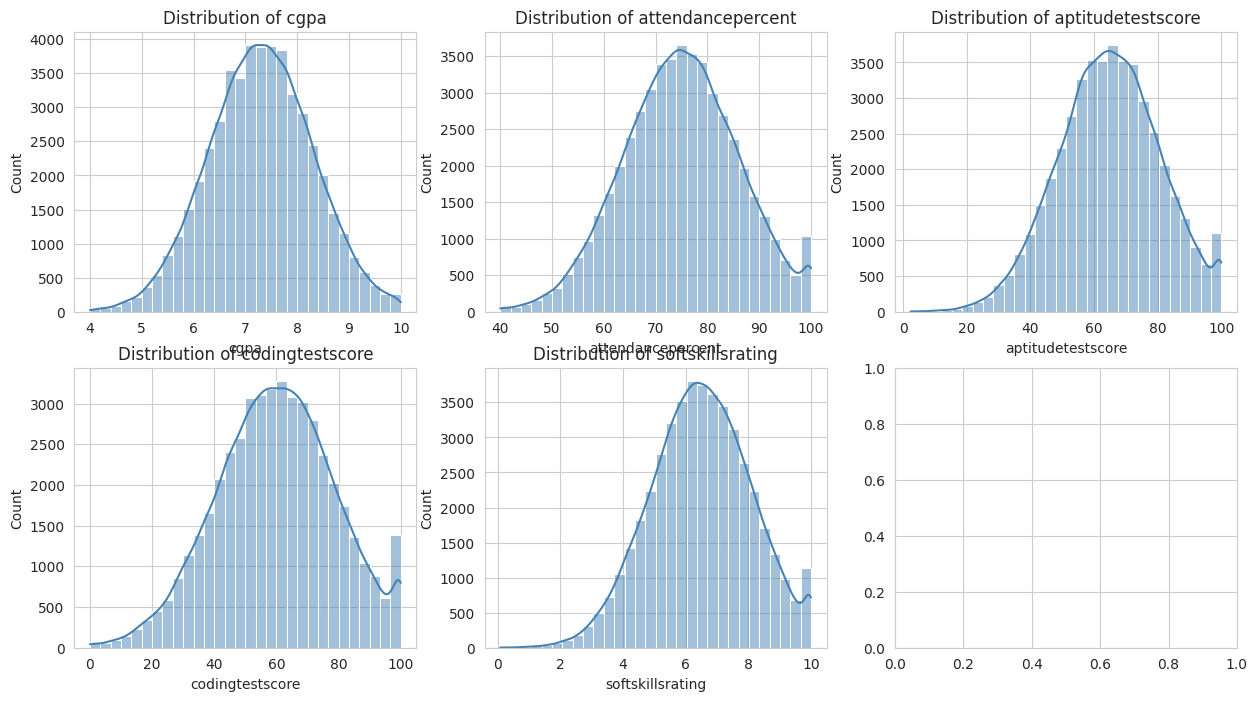

In [ ]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

# num_cols is now standardized in the previous cell to match the DataFrame's column names
for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages('EDA_Report.pdf') as pdf:
    pdf.savefig(fig1)
    pdf.savefig(fig2)

files.download('EDA_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

KeyError: 'salarypackage'

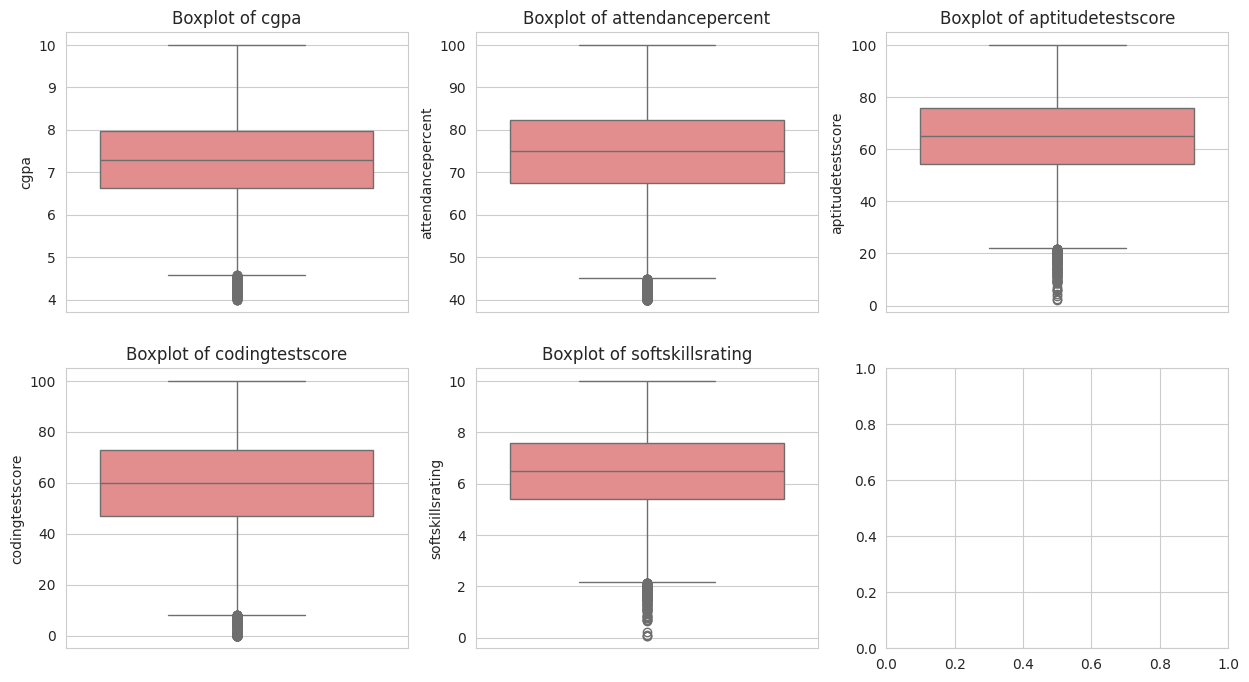

In [ ]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

# Correct the 'salary_package' entry in num_cols for this cell's execution,
# assuming the actual standardized column name is 'salarypackage'.
local_num_cols = [col if col != 'salary_package' else 'salarypackage' for col in num_cols]

for i, col in enumerate(local_num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

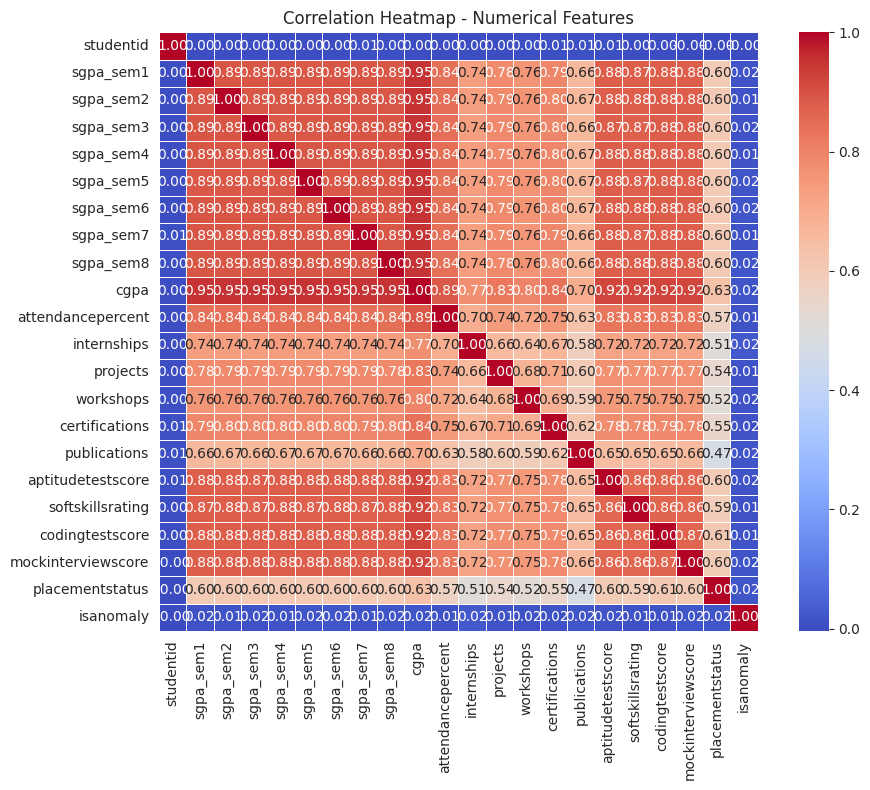

In [ ]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()